In [220]:
import pandas as pd

df = pd.read_csv("data/raw/store_performance.csv")

df.head()

,date,hour,employee_id,employee_name,hours_worked,customer_traffic,transactions,sales_revenue,sales_target,product_category,units_sold,accessory_sales,customer_rating,wait_time_minutes
0,2026-01-01,9,E002,Noah,1,5,2,255.29,300.0,Internet,6,0,4.3,3.9
1,2026-01-01,9,E006,Arjun,1,5,2,258.22,300.0,Mobile,6,0,4.1,3.4
2,2026-01-01,9,E005,Zara,1,6,2,355.22,300.0,Accessories,5,0,4.6,5.8
3,2026-01-01,10,E003,Mia,1,7,3,380.10,300.0,Accessories,7,0,4.1,4.8
4,2026-01-01,10,E005,Zara,1,7,2,513.21,300.0,Mobile,2,0,4.3,3.2


In [221]:
df.shape

(1606, 14)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1606 non-null   object 
 1   hour               1606 non-null   int64  
 2   employee_id        1606 non-null   object 
 3   employee_name      1606 non-null   object 
 4   hours_worked       1606 non-null   int64  
 5   customer_traffic   1606 non-null   int64  
 6   transactions       1606 non-null   int64  
 7   sales_revenue      1606 non-null   float64
 8   sales_target       1606 non-null   float64
 9   product_category   1606 non-null   object 
 10  units_sold         1606 non-null   int64  
 11  accessory_sales    1606 non-null   int64  
 12  customer_rating    1606 non-null   float64
 13  wait_time_minutes  1606 non-null   float64
dtypes: float64(4), int64(6), object(4)
memory usage: 175.8+ KB


In [223]:
df.isnull().sum()

date                 0
hour                 0
employee_id          0
employee_name        0
hours_worked         0
customer_traffic     0
transactions         0
sales_revenue        0
sales_target         0
product_category     0
units_sold           0
accessory_sales      0
customer_rating      0
wait_time_minutes    0
dtype: int64

In [224]:
df.duplicated().sum()

0

In [225]:
print("Transactions greater than customer traffic:",
      (df["transactions"] > df["customer_traffic"]).sum())

print("Negative sales:",
      (df["sales_revenue"] < 0).sum())

print("Invalid customer ratings:",
      ((df["customer_rating"] < 1) | (df["customer_rating"] > 5)).sum())

print("Negative wait times:",
      (df["wait_time_minutes"] < 0).sum())

Transactions greater than customer traffic: 0
Negative sales: 0
Invalid customer ratings: 0
Negative wait times: 0


In [226]:
df["conversion_rate"] = (
    df["transactions"] / df["customer_traffic"]
) * 100

df[[
    "customer_traffic",
    "transactions",
    "conversion_rate"
]].head(10)

,customer_traffic,transactions,conversion_rate
0,5,2,40.000000
1,5,2,40.000000
2,6,2,33.333333
3,7,3,42.857143
4,7,2,28.571429
5,8,4,50.000000
6,5,2,40.000000
7,2,0,0.000000
8,3,1,33.333333
9,3,0,0.000000


In [227]:
df["target_achievement_pct"] = (
    df["sales_revenue"] / df["sales_target"]
) * 100

df[[
    "sales_revenue",
    "sales_target",
    "target_achievement_pct"
]].head(10)

,sales_revenue,sales_target,target_achievement_pct
0,255.29,300.0,85.096667
1,258.22,300.0,86.073333
2,355.22,300.0,118.406667
3,380.10,300.0,126.700000
4,513.21,300.0,171.070000
5,491.70,300.0,163.900000
6,354.86,225.0,157.715556
7,0.00,225.0,0.000000
8,272.91,225.0,121.293333
9,0.00,225.0,0.000000


In [228]:
df["average_transaction_value"] = (
    df["sales_revenue"] /
    df["transactions"].replace(0, pd.NA)
)

df[[
    "sales_revenue",
    "transactions",
    "average_transaction_value"
]].head(10)

,sales_revenue,transactions,average_transaction_value
0,255.29,2,127.645
1,258.22,2,129.11
2,355.22,2,177.61
3,380.10,3,126.7
4,513.21,2,256.605
5,491.70,4,122.925
6,354.86,2,177.43
7,0.00,0,<NA>
8,272.91,1,272.91
9,0.00,0,<NA>


In [229]:
df[[
    "conversion_rate",
    "target_achievement_pct",
    "average_transaction_value"
]].describe()

,conversion_rate,target_achievement_pct
count,1606.000000,1606.000000
mean,31.777308,124.577289
std,13.563663,75.557502
min,0.000000,0.000000
25%,25.000000,73.572593
50%,33.333333,115.483457
75%,40.000000,169.981481
max,66.666667,522.858667


In [230]:
average_target = df["target_achievement_pct"].mean()

print(f"Average Target Achievement: {average_target:.2f}%")

Average Target Achievement: 124.58%


In [231]:
below_target = (df["target_achievement_pct"] < 100).sum()
above_target = (df["target_achievement_pct"] >= 100).sum()

print("Records below target:", below_target)
print("Records meeting or exceeding target:", above_target)

Records below target: 658
Records meeting or exceeding target: 948


In [232]:
hourly_performance = df.groupby("hour").agg({
    "sales_revenue": "sum",
    "sales_target": "sum",
    "customer_traffic": "sum",
    "transactions": "sum"
}).reset_index()

hourly_performance["target_achievement_pct"] = (
    hourly_performance["sales_revenue"] /
    hourly_performance["sales_target"]
) * 100

hourly_performance

,hour,sales_revenue,sales_target,customer_traffic,transactions,target_achievement_pct
0,9,68653.00,58050.00,982,316,118.265289
1,10,73426.47,58050.00,1047,353,126.488320
2,11,72273.85,58050.00,1036,342,124.502756
3,12,108847.81,78367.62,1404,517,138.893857
4,13,106398.97,78367.64,1454,511,135.769011
5,14,68698.17,58050.00,997,339,118.343101
6,15,66959.45,58050.00,1000,323,115.347890
7,16,114755.67,78367.64,1453,521,146.432469
8,17,107717.99,78367.65,1418,518,137.452112


In [233]:
staffing = df.groupby(["date", "hour"])["employee_id"].nunique().reset_index()

staffing.rename(
    columns={"employee_id": "staff_on_floor"},
    inplace=True
)

staffing.head()

,date,hour,staff_on_floor
0,2026-01-01,9,3
1,2026-01-01,10,3
2,2026-01-01,11,4
3,2026-01-01,12,2
4,2026-01-01,13,4


In [234]:
df = df.merge(
    staffing,
    on=["date", "hour"],
    how="left"
)

df[[
    "date",
    "hour",
    "employee_id",
    "customer_traffic",
    "staff_on_floor"
]].head(10)

,date,hour,employee_id,customer_traffic,staff_on_floor
0,2026-01-01,9,E002,5,3
1,2026-01-01,9,E006,5,3
2,2026-01-01,9,E005,6,3
3,2026-01-01,10,E003,7,3
4,2026-01-01,10,E005,7,3
5,2026-01-01,10,E006,8,3
6,2026-01-01,11,E006,5,4
7,2026-01-01,11,E001,2,4
8,2026-01-01,11,E002,3,4
9,2026-01-01,11,E003,3,4


In [235]:
df["staffing_pressure"] = (
    df["customer_traffic"] / df["staff_on_floor"]
)

df[[
    "customer_traffic",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes"
]].head(10)

,customer_traffic,staff_on_floor,staffing_pressure,wait_time_minutes
0,5,3,1.666667,3.9
1,5,3,1.666667,3.4
2,6,3,2.000000,5.8
3,7,3,2.333333,4.8
4,7,3,2.333333,3.2
5,8,3,2.666667,3.6
6,5,4,1.250000,5.3
7,2,4,0.500000,2.8
8,3,4,0.750000,5.0
9,3,4,0.750000,3.1


In [236]:
correlation = df["staffing_pressure"].corr(
    df["wait_time_minutes"]
)

print(f"Correlation: {correlation:.2f}")

Correlation: 0.39


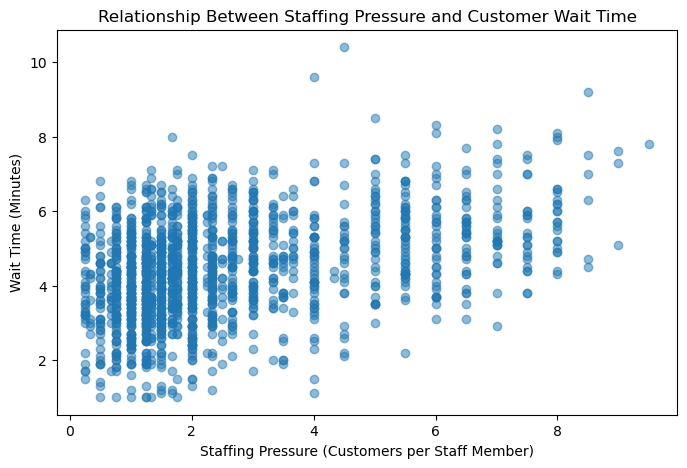

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["staffing_pressure"],
    df["wait_time_minutes"],
    alpha=0.5
)

plt.xlabel("Staffing Pressure (Customers per Staff Member)")
plt.ylabel("Wait Time (Minutes)")
plt.title("Relationship Between Staffing Pressure and Customer Wait Time")

plt.show()

In [238]:
pressure_threshold = df["staffing_pressure"].median()
wait_threshold = df["wait_time_minutes"].median()

print(f"Typical staffing pressure: {pressure_threshold:.2f}")
print(f"Typical wait time: {wait_threshold:.2f} minutes")

Typical staffing pressure: 1.75
Typical wait time: 4.40 minutes


## Customer Demand Analysis

This section analyses customer traffic patterns by hour to identify periods of high customer demand.

In [240]:
hourly_traffic = (
    df.groupby("hour")["customer_traffic"]
    .sum()
    .reset_index()
)

hourly_traffic

,hour,customer_traffic
0,9,982
1,10,1047
2,11,1036
3,12,1404
4,13,1454
5,14,997
6,15,1000
7,16,1453
8,17,1418


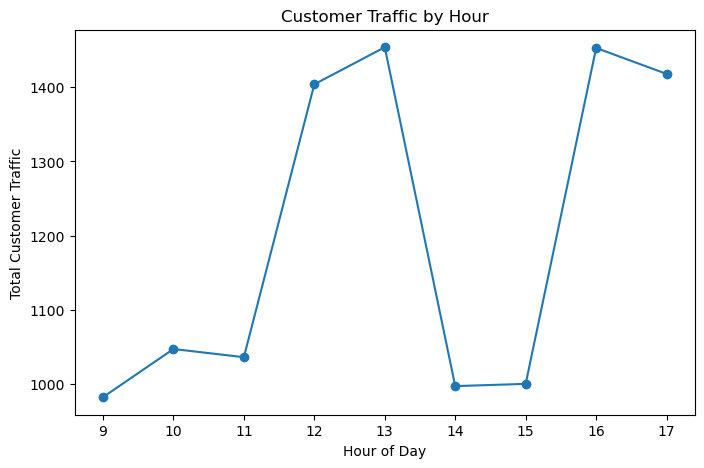

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["customer_traffic"],
    marker="o"
)

plt.title("Customer Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Customer Traffic")
plt.xticks(hourly_traffic["hour"])

plt.show()

## Customer Demand vs Staffing Levels

This analysis compares hourly customer traffic with staffing levels to identify whether staffing allocation aligns with periods of customer demand.

In [243]:
hourly_staffing = (
    df.groupby("hour")
    .agg(
        customer_traffic=("customer_traffic", "sum"),
        average_staff_on_floor=("staff_on_floor", "mean")
    )
    .reset_index()
)

hourly_staffing

,hour,customer_traffic,average_staff_on_floor
0,9,982,3.282609
1,10,1047,3.178771
2,11,1036,3.182857
3,12,1404,3.169492
4,13,1454,3.180791
5,14,997,3.301075
6,15,1000,3.310160
7,16,1453,3.012048
8,17,1418,3.160000


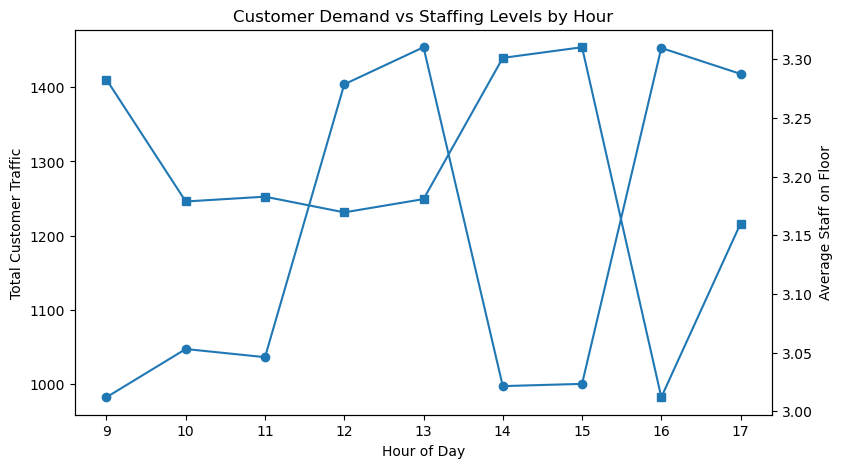

In [244]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    hourly_staffing["hour"],
    hourly_staffing["customer_traffic"],
    marker="o"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total Customer Traffic")

ax2 = ax1.twinx()

ax2.plot(
    hourly_staffing["hour"],
    hourly_staffing["average_staff_on_floor"],
    marker="s"
)

ax2.set_ylabel("Average Staff on Floor")

plt.title("Customer Demand vs Staffing Levels by Hour")
plt.show()

In [245]:
hourly_staffing["customers_per_staff"] = (
    hourly_staffing["customer_traffic"] /
    hourly_staffing["average_staff_on_floor"]
)

hourly_staffing[[
    "hour",
    "customer_traffic",
    "average_staff_on_floor",
    "customers_per_staff"
]].sort_values(
    "customers_per_staff",
    ascending=False
)

,hour,customer_traffic,average_staff_on_floor,customers_per_staff
7,16,1453,3.012048,482.396000
4,13,1454,3.180791,457.119005
8,17,1418,3.160000,448.734177
3,12,1404,3.169492,442.973262
1,10,1047,3.178771,329.372583
2,11,1036,3.182857,325.493716
6,15,1000,3.310160,302.100162
5,14,997,3.301075,302.022801
0,9,982,3.282609,299.152318


In [246]:
# Normalise the three factors to a 0–1 scale

df["pressure_norm"] = (
    df["staffing_pressure"] - df["staffing_pressure"].min()
) / (
    df["staffing_pressure"].max() - df["staffing_pressure"].min()
)

df["wait_norm"] = (
    df["wait_time_minutes"] - df["wait_time_minutes"].min()
) / (
    df["wait_time_minutes"].max() - df["wait_time_minutes"].min()
)

df["rating_risk_norm"] = (
    df["customer_rating"].max() - df["customer_rating"]
) / (
    df["customer_rating"].max() - df["customer_rating"].min()
)

In [247]:
df["staffing_risk_score"] = (
    0.4 * df["pressure_norm"] +
    0.4 * df["wait_norm"] +
    0.2 * df["rating_risk_norm"]
) * 100

In [248]:
df[[
    "date",
    "hour",
    "staffing_pressure",
    "wait_time_minutes",
    "customer_rating",
    "staffing_risk_score"
]].sort_values(
    "staffing_risk_score",
    ascending=False
).head(10)

,date,hour,staffing_pressure,wait_time_minutes,customer_rating,staffing_risk_score
281,2026-01-11,13,8.5,9.2,3.6,88.069293
1282,2026-02-17,16,9.5,7.8,3.6,86.436170
69,2026-01-03,13,9.0,7.3,3.8,79.646348
1506,2026-02-26,13,8.0,7.9,3.9,76.625216
831,2026-02-01,11,8.5,7.5,4.1,74.585250
1008,2026-02-07,16,8.0,8.1,4.2,73.726279
108,2026-01-04,17,8.5,7.0,4.0,73.707591
823,2026-01-31,17,8.0,8.0,4.2,73.300748
143,2026-01-06,12,4.5,10.4,3.9,72.128378
1416,2026-02-22,17,8.0,6.2,3.7,71.891173


## Staffing Risk Classification

The staffing risk score is classified into Low, Medium, and High risk levels to make operational risks easier for managers to identify and prioritise.

In [250]:
def classify_risk(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

df["staffing_risk_level"] = df["staffing_risk_score"].apply(classify_risk)

df["staffing_risk_level"].value_counts()

staffing_risk_level
Low       1166
Medium     427
High        13
Name: count, dtype: int64

In [251]:
high_risk_periods = df[
    df["staffing_risk_level"] == "High"
][[
    "date",
    "hour",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes",
    "customer_rating",
    "staffing_risk_score"
]].sort_values(
    "staffing_risk_score",
    ascending=False
)

high_risk_periods.head(10)

,date,hour,staff_on_floor,staffing_pressure,wait_time_minutes,customer_rating,staffing_risk_score
281,2026-01-11,13,2,8.5,9.2,3.6,88.069293
1282,2026-02-17,16,2,9.5,7.8,3.6,86.436170
69,2026-01-03,13,2,9.0,7.3,3.8,79.646348
1506,2026-02-26,13,2,8.0,7.9,3.9,76.625216
831,2026-02-01,11,2,8.5,7.5,4.1,74.585250
1008,2026-02-07,16,2,8.0,8.1,4.2,73.726279
108,2026-01-04,17,2,8.5,7.0,4.0,73.707591
823,2026-01-31,17,2,8.0,8.0,4.2,73.300748
143,2026-01-06,12,2,4.5,10.4,3.9,72.128378
1416,2026-02-22,17,2,8.0,6.2,3.7,71.891173


In [252]:
high_risk_periods = df[
    df["staffing_risk_level"] == "High"
][[
    "date",
    "hour",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes",
    "customer_rating",
    "staffing_risk_score"
]].sort_values(
    "staffing_risk_score",
    ascending=False
)

high_risk_periods.head(10)

,date,hour,staff_on_floor,staffing_pressure,wait_time_minutes,customer_rating,staffing_risk_score
281,2026-01-11,13,2,8.5,9.2,3.6,88.069293
1282,2026-02-17,16,2,9.5,7.8,3.6,86.436170
69,2026-01-03,13,2,9.0,7.3,3.8,79.646348
1506,2026-02-26,13,2,8.0,7.9,3.9,76.625216
831,2026-02-01,11,2,8.5,7.5,4.1,74.585250
1008,2026-02-07,16,2,8.0,8.1,4.2,73.726279
108,2026-01-04,17,2,8.5,7.0,4.0,73.707591
823,2026-01-31,17,2,8.0,8.0,4.2,73.300748
143,2026-01-06,12,2,4.5,10.4,3.9,72.128378
1416,2026-02-22,17,2,8.0,6.2,3.7,71.891173


## Manager Recommendations

This section converts staffing risk classifications into simple operational recommendations that a store manager could use to prioritise staffing decisions.

In [254]:
def generate_recommendation(row):
    if row["staffing_risk_level"] == "High":
        return "Review staffing allocation and consider adding or reallocating staff."
    
    elif row["staffing_risk_level"] == "Medium":
        return "Monitor customer demand and wait times."
    
    else:
        return "No immediate staffing action required."


df["manager_recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)

In [255]:
df[[
    "date",
    "hour",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes",
    "customer_rating",
    "staffing_risk_score",
    "staffing_risk_level",
    "manager_recommendation"
]].sort_values(
    "staffing_risk_score",
    ascending=False
).head(10)

,date,hour,staff_on_floor,staffing_pressure,wait_time_minutes,customer_rating,staffing_risk_score,staffing_risk_level,manager_recommendation
281,2026-01-11,13,2,8.5,9.2,3.6,88.069293,High,Review staffing allocation and consider adding...
1282,2026-02-17,16,2,9.5,7.8,3.6,86.436170,High,Review staffing allocation and consider adding...
69,2026-01-03,13,2,9.0,7.3,3.8,79.646348,High,Review staffing allocation and consider adding...
1506,2026-02-26,13,2,8.0,7.9,3.9,76.625216,High,Review staffing allocation and consider adding...
831,2026-02-01,11,2,8.5,7.5,4.1,74.585250,High,Review staffing allocation and consider adding...
1008,2026-02-07,16,2,8.0,8.1,4.2,73.726279,High,Review staffing allocation and consider adding...
108,2026-01-04,17,2,8.5,7.0,4.0,73.707591,High,Review staffing allocation and consider adding...
823,2026-01-31,17,2,8.0,8.0,4.2,73.300748,High,Review staffing allocation and consider adding...
143,2026-01-06,12,2,4.5,10.4,3.9,72.128378,High,Review staffing allocation and consider adding...
1416,2026-02-22,17,2,8.0,6.2,3.7,71.891173,High,Review staffing allocation and consider adding...


df[[
    "date",
    "hour",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes",
    "customer_rating",
    "staffing_risk_score",
    "staffing_risk_level",
    "manager_recommendation"
]].sort_values(
    "staffing_risk_score",
    ascending=False
).head(10)

## Explainable Staffing Risk

To make StorePilot more useful, each flagged period includes a short explanation of the factors contributing to the staffing risk score.

In [258]:
def explain_risk(row):
    reasons = []

    if row["pressure_norm"] >= 0.7:
        reasons.append("high customer demand per staff member")

    if row["wait_norm"] >= 0.7:
        reasons.append("long customer wait time")

    if row["rating_risk_norm"] >= 0.7:
        reasons.append("lower customer satisfaction")

    if not reasons:
        return "No major operational risk factors detected."

    return ", ".join(reasons)


df["risk_explanation"] = df.apply(
    explain_risk,
    axis=1
)

In [259]:
df[[
    "date",
    "hour",
    "staffing_risk_score",
    "staffing_risk_level",
    "risk_explanation",
    "manager_recommendation"
]].sort_values(
    "staffing_risk_score",
    ascending=False
).head(10)

,date,hour,staffing_risk_score,staffing_risk_level,risk_explanation,manager_recommendation
281,2026-01-11,13,88.069293,High,"high customer demand per staff member, long cu...",Review staffing allocation and consider adding...
1282,2026-02-17,16,86.436170,High,"high customer demand per staff member, long cu...",Review staffing allocation and consider adding...
69,2026-01-03,13,79.646348,High,"high customer demand per staff member, lower c...",Review staffing allocation and consider adding...
1506,2026-02-26,13,76.625216,High,"high customer demand per staff member, long cu...",Review staffing allocation and consider adding...
831,2026-02-01,11,74.585250,High,high customer demand per staff member,Review staffing allocation and consider adding...
1008,2026-02-07,16,73.726279,High,"high customer demand per staff member, long cu...",Review staffing allocation and consider adding...
108,2026-01-04,17,73.707591,High,high customer demand per staff member,Review staffing allocation and consider adding...
823,2026-01-31,17,73.300748,High,"high customer demand per staff member, long cu...",Review staffing allocation and consider adding...
143,2026-01-06,12,72.128378,High,long customer wait time,Review staffing allocation and consider adding...
1416,2026-02-22,17,71.891173,High,"high customer demand per staff member, lower c...",Review staffing allocation and consider adding...


# Staffing Optimisation

Estimate the number of additional staff required during busy periods based on customer traffic.

In [261]:
import math

TARGET_CUSTOMERS_PER_STAFF = 12

In [262]:
def recommend_extra_staff(row):
    required_staff = math.ceil(
        row["customer_traffic"] / TARGET_CUSTOMERS_PER_STAFF
    )

    return max(0, required_staff - row["staff_on_floor"])


df["recommended_extra_staff"] = df.apply(
    recommend_extra_staff,
    axis=1
)

In [263]:
def recommend_extra_staff(row):
    required_staff = math.ceil(
        row["customer_traffic"] / TARGET_CUSTOMERS_PER_STAFF
    )

    return max(0, required_staff - row["staff_on_floor"])


df["recommended_extra_staff"] = df.apply(
    recommend_extra_staff,
    axis=1
)

In [302]:
staffing_recommendations = (
    df[
        [
            "date",
            "hour",
            "customer_traffic",
            "staff_on_floor",
            "recommended_extra_staff",
            "staffing_risk_score",
        ]
    ]
    .sort_values(
        by="recommended_extra_staff",
        ascending=False
    )
)

staffing_recommendations.head(20)

,date,hour,customer_traffic,staff_on_floor,recommended_extra_staff,staffing_risk_score
0,2026-01-01,9,5,3,0,27.216552
1067,2026-02-10,9,5,4,0,39.749856
1077,2026-02-10,11,4,4,0,16.727286
1076,2026-02-10,11,5,4,0,30.015814
1075,2026-02-10,11,2,4,0,17.995975
1074,2026-02-10,11,4,4,0,25.982605
1073,2026-02-10,10,8,3,0,26.035557
1072,2026-02-10,10,5,3,0,39.423998
1071,2026-02-10,10,5,3,0,33.918679
1070,2026-02-10,9,5,4,0,18.154112


In [306]:
staffing_recommendations.to_csv(
    "../data/processed/staffing_recommendations.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '../data/processed'